0.
Задача классификации: анализ личности клиента для прогнозирования принятия маркетинговых предложений

Целевая переменная: Response (принял ли клиент предложение в последней кампании - 1: да, 0: нет)

Цель - построить модель, которая сможет предсказать, примет ли клиент маркетинговое предложение.

1. Чтение данных

In [152]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
%matplotlib inline

url = 'https://raw.githubusercontent.com/kintoqq/machine_learning/refs/heads/main/marketing_campaign.csv'
data = pd.read_csv(url, sep='\t', header=0,  engine='python')

data['Education'] = data['Education'].astype('category')
data['Marital_Status'] = data['Marital_Status'].astype('category')

data.isnull().sum()



,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Предобработка данных


In [153]:
income_median = data['Income'].median()
data_clean = data.copy()
data_clean['Income'] = data_clean['Income'].fillna(income_median)

data_clean['Age'] = 2025 - data_clean['Year_Birth']

data_clean['TotalSpent'] = data_clean[['MntWines', 'MntFruits', 'MntMeatProducts',
                                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

data_clean['NumTotalPurchases'] = data_clean[['NumWebPurchases', 'NumCatalogPurchases',
                                            'NumStorePurchases', 'NumDealsPurchases']].sum(axis=1)

data_clean['Children'] = data_clean['Kidhome'] + data_clean['Teenhome']

data_clean['CustomerSeniority'] = 2023 - pd.to_datetime(data_clean['Dt_Customer'], dayfirst=True).dt.year

cols_to_drop = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue','MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
    'Kidhome', 'Teenhome']
data_clean = data_clean.drop([col for col in cols_to_drop if col in data_clean.columns], axis=1)

print(f"Новый размер данных: {data_clean.shape}")
print("\nОставшиеся признаки:")
print(data_clean.columns.tolist())
data_clean.head()

Новый размер данных: (2240, 17)

Оставшиеся признаки:
['Education', 'Marital_Status', 'Income', 'Recency', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'TotalSpent', 'NumTotalPurchases', 'Children', 'CustomerSeniority']


,Education,Marital_Status,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
0,Graduation,Single,58138.0,58,7,0,0,0,0,0,0,1,68,1617,25,0,11
1,Graduation,Single,46344.0,38,5,0,0,0,0,0,0,0,71,27,6,2,9
2,Graduation,Together,71613.0,26,4,0,0,0,0,0,0,0,60,776,21,0,10
3,Graduation,Together,26646.0,26,6,0,0,0,0,0,0,0,41,53,8,1,9
4,PhD,Married,58293.0,94,5,0,0,0,0,0,0,0,44,422,19,1,9


In [154]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Education          2240 non-null   category
 1   Marital_Status     2240 non-null   category
 2   Income             2240 non-null   float64 
 3   Recency            2240 non-null   int64   
 4   NumWebVisitsMonth  2240 non-null   int64   
 5   AcceptedCmp3       2240 non-null   int64   
 6   AcceptedCmp4       2240 non-null   int64   
 7   AcceptedCmp5       2240 non-null   int64   
 8   AcceptedCmp1       2240 non-null   int64   
 9   AcceptedCmp2       2240 non-null   int64   
 10  Complain           2240 non-null   int64   
 11  Response           2240 non-null   int64   
 12  Age                2240 non-null   int64   
 13  TotalSpent         2240 non-null   int64   
 14  NumTotalPurchases  2240 non-null   int64   
 15  Children           2240 non-null   int64   
 16  Custom

2. Обучающая и тестовая выборки

In [155]:
X = data_clean.drop(['Response'], axis=1)
y = data_clean['Response']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

N_train, _ = X_train.shape
N_test,  _ = X_test.shape

N_train, N_test

(1680, 560)

3. Визуализацияя и основные характеристики

In [156]:
# числовые признаки
numeric_features = data_clean.select_dtypes(include=[np.number]).columns
print("Числовые признаки:", len(numeric_features))

# категориальнык признаки
categorical_features = data_clean.select_dtypes(include=['category']).columns
print("Категориальные признаки:", len(categorical_features))
print("Категориальные признаки:", list(categorical_features))

Числовые признаки: 15
Категориальные признаки: 2
Категориальные признаки: ['Education', 'Marital_Status']


In [157]:
for feature in categorical_features:
    print(f"\n{feature}:")
    print(data_clean[feature].value_counts())
    print(f"Категории: {list(data_clean[feature].cat.categories)}")


Education:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Категории: ['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']

Marital_Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Категории: ['Absurd', 'Alone', 'Divorced', 'Married', 'Single', 'Together', 'Widow', 'YOLO']


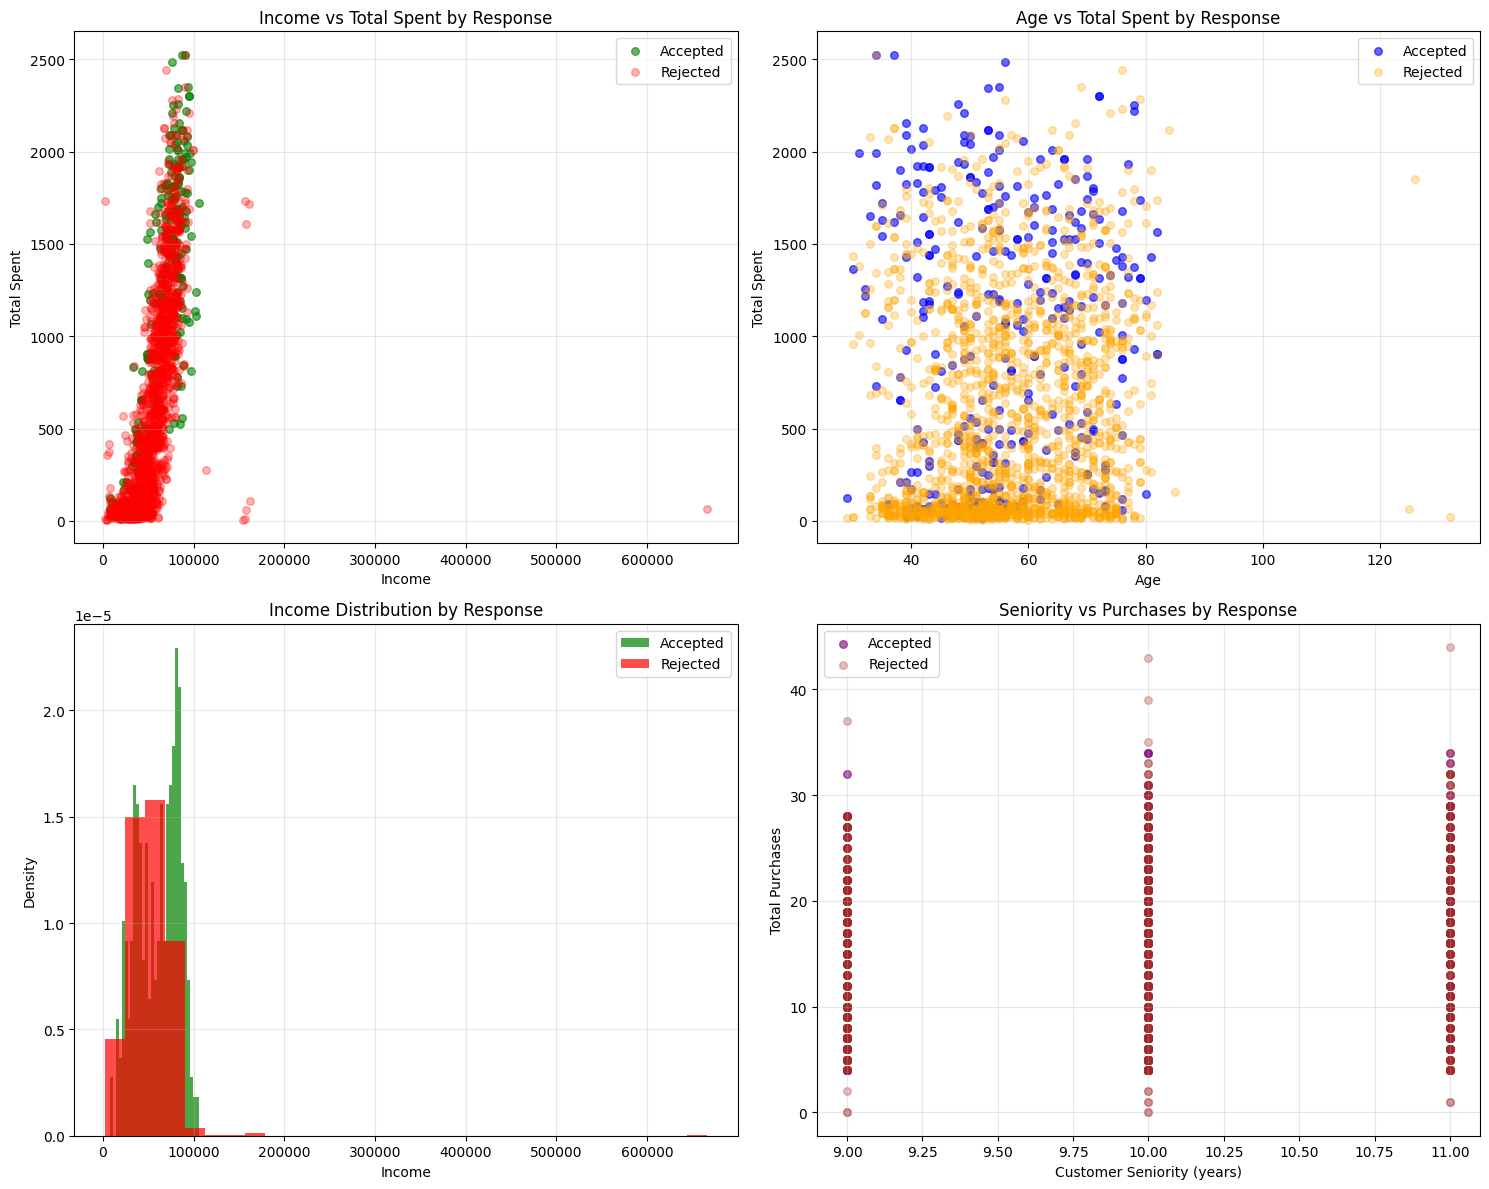

In [158]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
accepted = data_clean[data_clean['Response'] == 1]
rejected = data_clean[data_clean['Response'] == 0]

plt.scatter(accepted['Income'], accepted['TotalSpent'],
           alpha=0.6, color='green', label='Accepted', s=30)
plt.scatter(rejected['Income'], rejected['TotalSpent'],
           alpha=0.3, color='red', label='Rejected', s=30)
plt.xlabel('Income')
plt.ylabel('Total Spent')
plt.title('Income vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(accepted['Age'], accepted['TotalSpent'],
           alpha=0.6, color='blue', label='Accepted', s=30)
plt.scatter(rejected['Age'], rejected['TotalSpent'],
           alpha=0.3, color='orange', label='Rejected', s=30)
plt.xlabel('Age')
plt.ylabel('Total Spent')
plt.title('Age vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(accepted['Income'], bins=30, alpha=0.7, color='green',
         label='Accepted', density=True)
plt.hist(rejected['Income'], bins=30, alpha=0.7, color='red',
         label='Rejected', density=True)
plt.xlabel('Income')
plt.ylabel('Density')
plt.title('Income Distribution by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(accepted['CustomerSeniority'], accepted['NumTotalPurchases'],
           alpha=0.6, color='purple', label='Accepted', s=30)
plt.scatter(rejected['CustomerSeniority'], rejected['NumTotalPurchases'],
           alpha=0.3, color='brown', label='Rejected', s=30)
plt.xlabel('Customer Seniority (years)')
plt.ylabel('Total Purchases')
plt.title('Seniority vs Purchases by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Можно заметить выбросы в доходе и возрасте, нужно это исправить

In [159]:
data_clean.quantile([0.005,.01,.05,.1,.5,.9,.95,.99,.995], numeric_only=True)

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
0.005,7500.00,0.0,1.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.000,10.00,4.0,0.0,9.0
0.010,7705.92,0.0,1.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.000,13.00,4.0,0.0,9.0
0.050,19101.05,4.0,1.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.000,22.00,4.0,0.0,9.0
0.100,24219.50,9.0,2.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.000,34.90,5.0,0.0,9.0
0.500,51381.50,49.0,6.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.000,396.00,15.0,1.0,10.0
0.900,79800.30,89.0,8.000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,73.000,1536.20,25.0,2.0,11.0
0.950,83927.00,94.0,8.000,1.0,1.0,1.0,1.0,0.0,0.0,1.0,75.000,1772.30,27.0,2.0,11.0
0.990,94437.68,98.0,9.000,1.0,1.0,1.0,1.0,1.0,0.0,1.0,80.000,2126.00,32.0,3.0,11.0
0.995,102122.95,99.0,9.805,1.0,1.0,1.0,1.0,1.0,1.0,1.0,81.805,2274.71,33.0,3.0,11.0


In [160]:
rows_to_drop = data_clean[
    (data_clean['Income'] < data_clean['Income'].quantile(0.005)) | (data_clean['Income'] > data_clean['Income'].quantile(0.995)) |
    (data_clean['Age'] < data_clean['Age'].quantile(0.005)) | (data_clean['Age'] > data_clean['Age'].quantile(0.995))].index
data_clean = data_clean.drop(rows_to_drop)
data_clean.describe()

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
count,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000
mean,51676.941458,49.125285,5.313895,0.071982,0.074715,0.069704,0.063781,0.012756,0.008200,0.148064,56.113895,602.905239,14.834624,0.961731,9.974032
std,20215.028550,28.986500,2.297865,0.258517,0.262991,0.254705,0.244419,0.112247,0.090205,0.355244,11.511508,599.384250,7.555838,0.749593,0.684348
min,7500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,8.000000,1.000000,0.000000,9.000000
25%,35686.000000,24.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,69.000000,8.000000,0.000000,10.000000
50%,51381.500000,49.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,396.000000,15.000000,1.000000,10.000000
75%,67902.000000,74.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,1038.500000,21.000000,1.000000,10.000000
max,101970.000000,99.000000,19.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,81.000000,2525.000000,39.000000,3.000000,11.000000


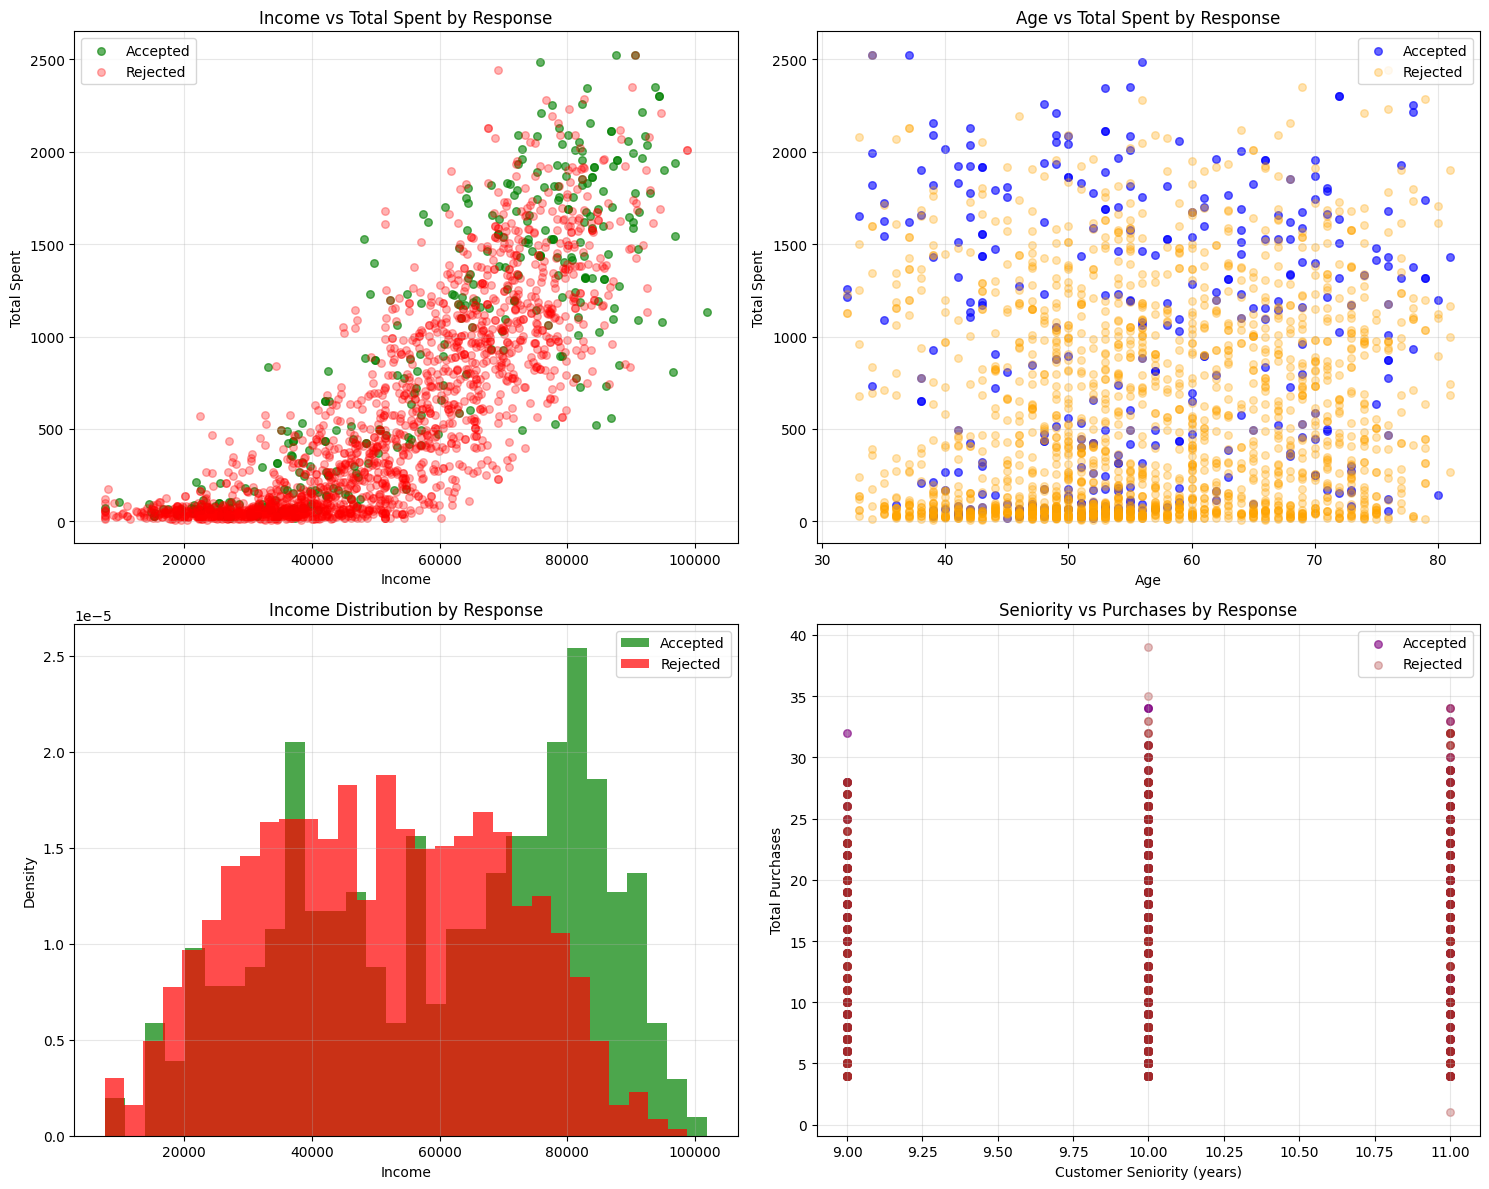

In [161]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
accepted = data_clean[data_clean['Response'] == 1]
rejected = data_clean[data_clean['Response'] == 0]

plt.scatter(accepted['Income'], accepted['TotalSpent'],
           alpha=0.6, color='green', label='Accepted', s=30)
plt.scatter(rejected['Income'], rejected['TotalSpent'],
           alpha=0.3, color='red', label='Rejected', s=30)
plt.xlabel('Income')
plt.ylabel('Total Spent')
plt.title('Income vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(accepted['Age'], accepted['TotalSpent'],
           alpha=0.6, color='blue', label='Accepted', s=30)
plt.scatter(rejected['Age'], rejected['TotalSpent'],
           alpha=0.3, color='orange', label='Rejected', s=30)
plt.xlabel('Age')
plt.ylabel('Total Spent')
plt.title('Age vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(accepted['Income'], bins=30, alpha=0.7, color='green',
         label='Accepted', density=True)
plt.hist(rejected['Income'], bins=30, alpha=0.7, color='red',
         label='Rejected', density=True)
plt.xlabel('Income')
plt.ylabel('Density')
plt.title('Income Distribution by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(accepted['CustomerSeniority'], accepted['NumTotalPurchases'],
           alpha=0.6, color='purple', label='Accepted', s=30)
plt.scatter(rejected['CustomerSeniority'], rejected['NumTotalPurchases'],
           alpha=0.3, color='brown', label='Rejected', s=30)
plt.xlabel('Customer Seniority (years)')
plt.ylabel('Total Purchases')
plt.title('Seniority vs Purchases by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3988779158.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_response = data_clean.groupby('Education')['Response'].mean()


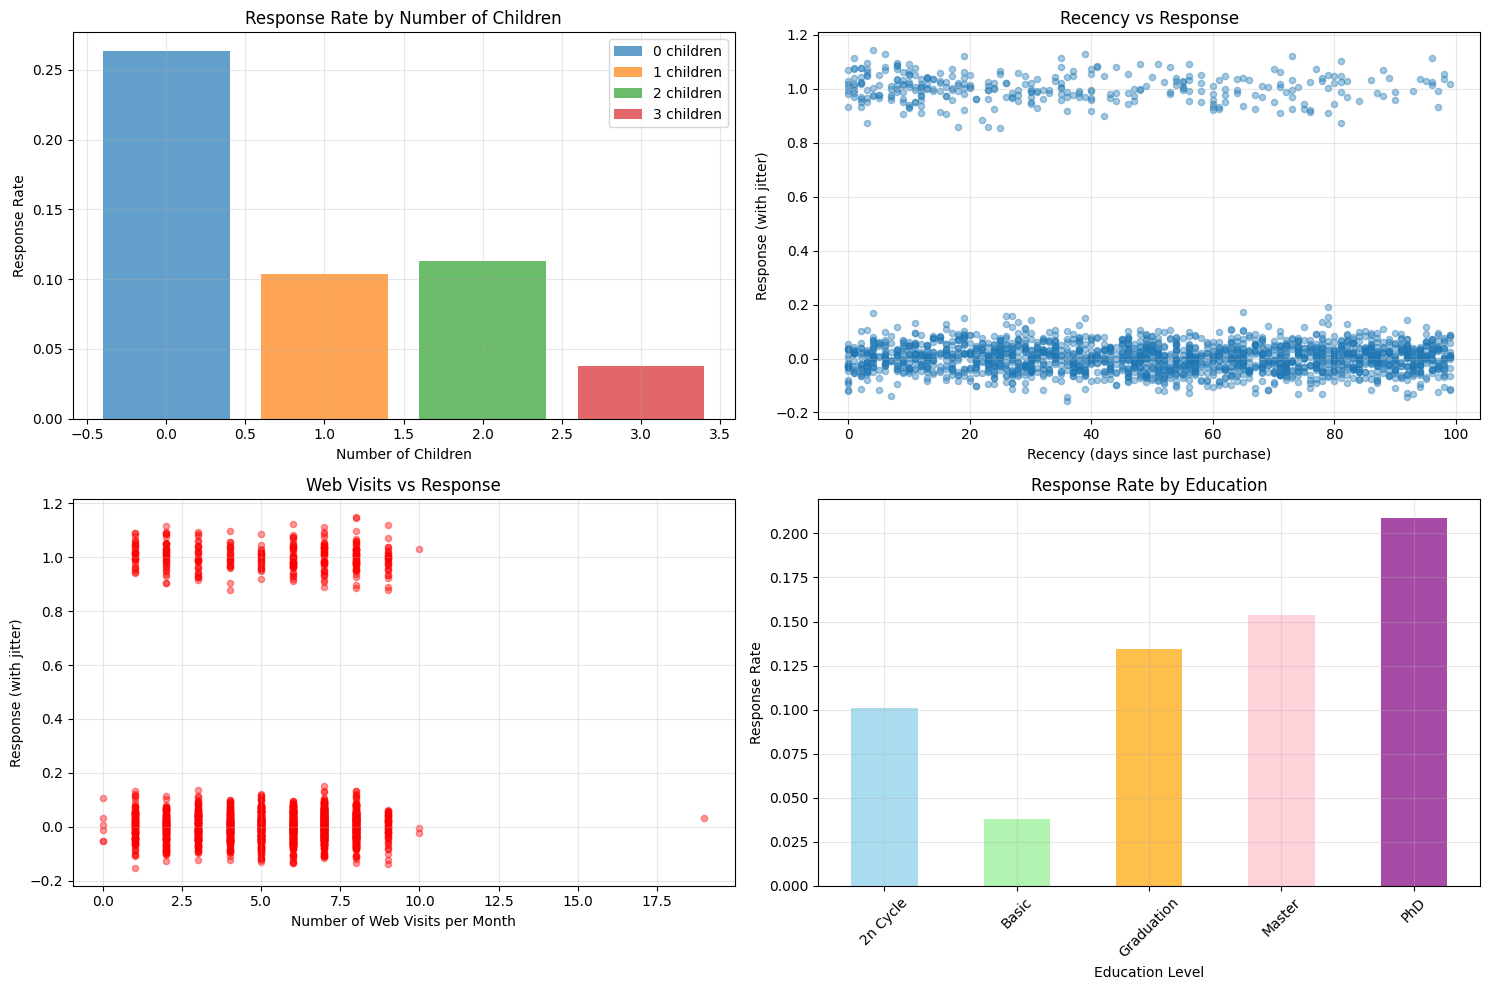

In [162]:
plt.figure(figsize=(15, 10))

# 1. Анализ Children vs Response
plt.subplot(2, 2, 1)
for children_count in sorted(data_clean['Children'].unique()):
    subset = data_clean[data_clean['Children'] == children_count]
    response_rate = subset['Response'].mean()
    plt.bar(children_count, response_rate, alpha=0.7,
            label=f'{children_count} children')
plt.xlabel('Number of Children')
plt.ylabel('Response Rate')
plt.title('Response Rate by Number of Children')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Recency vs Response
plt.subplot(2, 2, 2)
plt.scatter(data_clean['Recency'], data_clean['Response'] + np.random.normal(0, 0.05, len(data_clean)),
           alpha=0.4, s=20)
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Response (with jitter)')
plt.title('Recency vs Response')
plt.grid(True, alpha=0.3)

# 3. NumWebVisitsMonth vs Response
plt.subplot(2, 2, 3)
plt.scatter(data_clean['NumWebVisitsMonth'], data_clean['Response'] + np.random.normal(0, 0.05, len(data_clean)),
           alpha=0.4, s=20, color='red')
plt.xlabel('Number of Web Visits per Month')
plt.ylabel('Response (with jitter)')
plt.title('Web Visits vs Response')
plt.grid(True, alpha=0.3)

# 4. Анализ по Education
plt.subplot(2, 2, 4)
education_response = data_clean.groupby('Education')['Response'].mean()
education_response.plot(kind='bar', alpha=0.7, color=['skyblue', 'lightgreen', 'orange', 'pink', 'purple'])
plt.xlabel('Education Level')
plt.ylabel('Response Rate')
plt.title('Response Rate by Education')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

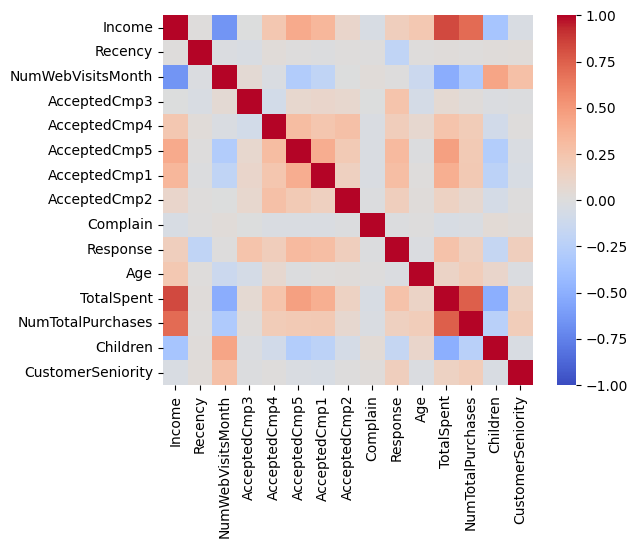

In [163]:
corr_mat = data_clean.corr(numeric_only=True)
corr_mat
sns.heatmap(corr_mat, square=True, vmin=-1, vmax=1, cmap='coolwarm')
pass

5. Обработка категориальных признаков

In [164]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='if_binary', sparse_output=False)
enc.fit(X_train[['Education', 'Marital_Status']])

OneHotEncoder(drop='if_binary', sparse_output=False)

In [165]:
dummies = pd.DataFrame(enc.transform(X_train[['Education', 'Marital_Status']]),
                       columns=enc.get_feature_names_out(), index=X_train.index)
dummies.head()

,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1315,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2220,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
889,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
780,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2021,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [166]:
X_train = pd.concat((X_train, dummies), axis=1).drop(['Education', 'Marital_Status'], axis=1)

In [167]:
X_train.head()

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1315,27238.0,39,9,0,0,0,0,0,0,63,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2220,58025.0,81,4,0,0,0,0,0,0,46,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
889,68092.0,7,5,0,0,0,0,0,0,47,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
780,71466.0,86,1,0,0,0,0,0,0,51,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2021,43815.0,53,6,0,0,0,0,0,0,43,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Масштабирование

In [168]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)

In [169]:
X_train.describe()

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
count,1.680000e+03,1.680000e+03,1.680000e+03,1680.000000,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,...,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03
mean,1.057355e-18,7.401487e-17,-1.818651e-16,0.000000,9.516197e-18,9.939139e-17,7.612958e-17,-1.691768e-17,5.286776e-18,-1.406282e-16,...,3.383537e-17,6.767074e-17,1.691768e-17,5.286776e-18,-2.537653e-17,2.960595e-17,-2.854859e-17,6.767074e-17,9.093255e-17,6.344132e-18
std,1.000298e+00,1.000298e+00,1.000298e+00,1.000298,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,...,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00
min,-1.910391e+00,-1.695709e+00,-2.168479e+00,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,-2.274543e+00,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,-8.043997e-01,-5.176143e-01,-5.910986e-01,-1.822370e-01,-3.452383e-02
25%,-6.498861e-01,-8.589060e-01,-9.442003e-01,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,-7.595171e-01,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,-8.043997e-01,-5.176143e-01,-5.910986e-01,-1.822370e-01,-3.452383e-02
50%,-2.918128e-02,1.276374e-02,2.800779e-01,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,-8.617212e-02,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,-8.043997e-01,-5.176143e-01,-5.910986e-01,-1.822370e-01,-3.452383e-02
75%,5.996244e-01,8.495667e-01,6.881707e-01,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,8.396772e-01,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,1.243163e+00,-5.176143e-01,1.691765e+00,-1.822370e-01,-3.452383e-02
max,2.340808e+01,1.756103e+00,5.993376e+00,3.542370,3.654993e+00,3.496905e+00,3.834180e+00,9.110434e+00,9.890578e+00,5.889764e+00,...,2.300464e+00,1.891469e+00,4.097560e+01,2.364318e+01,2.980328e+00,1.243163e+00,1.931941e+00,1.691765e+00,5.487359e+00,2.896550e+01


7. Обучение и тест модели

In [170]:
X_test

,Education,Marital_Status,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
324,Graduation,Single,40464.0,78,8,0,0,0,0,0,0,72,630,24,1,10
96,Graduation,Widow,47916.0,72,6,0,1,0,0,0,0,65,606,22,1,11
2104,Basic,Married,14188.0,40,6,0,0,0,0,0,0,53,75,7,0,10
1259,Graduation,Together,76653.0,91,2,0,0,1,1,0,0,56,2279,23,0,10
1061,Graduation,Together,65196.0,34,5,1,0,0,0,0,0,67,1155,26,2,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,Graduation,Married,67716.0,8,5,0,1,0,0,0,0,65,1016,28,1,10
1995,2n Cycle,Married,96547.0,4,2,1,0,1,1,0,0,45,809,21,0,9
305,Master,Married,80950.0,44,2,0,0,0,1,0,0,64,1213,23,0,10
209,Graduation,Divorced,64497.0,17,8,1,0,0,0,0,0,71,1804,29,1,11


In [171]:
dummies = pd.DataFrame(enc.transform(X_test[['Education', 'Marital_Status']]),
                       columns=enc.get_feature_names_out(), index=X_test.index)
X_test = pd.concat((X_test, dummies), axis=1).drop(['Education', 'Marital_Status'], axis=1)

X_test = pd.DataFrame(scaler.transform(X_test),
                      columns=X_test.columns, index=X_test.index)
X_test

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
324,-0.435534,1.023901,1.096263,-0.282297,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,1.344686,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,1.931941,-0.591099,-0.182237,-0.034524
96,-0.151788,0.814700,0.280078,-0.282297,3.654993,-0.285967,-0.260812,-0.109764,-0.101106,0.755509,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,-0.517614,-0.591099,5.487359,-0.034524
2104,-1.436034,-0.301037,0.280078,-0.282297,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,-0.254508,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
1259,0.942418,1.477169,-1.352293,-0.282297,-0.273598,3.496905,3.834180,-0.109764,-0.101106,-0.002004,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,-0.517614,1.691765,-0.182237,-0.034524
1061,0.506175,-0.510238,-0.128015,3.542370,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,0.923845,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,-0.517614,1.691765,-0.182237,-0.034524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,0.602128,-1.416775,-0.128015,-0.282297,3.654993,-0.285967,-0.260812,-0.109764,-0.101106,0.755509,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
1995,1.699913,-1.556242,-1.352293,3.542370,-0.273598,3.496905,3.834180,-0.109764,-0.101106,-0.927853,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
305,1.106033,-0.161570,-1.352293,-0.282297,-0.273598,-0.285967,3.834180,-0.109764,-0.101106,0.671341,...,2.300464,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
209,0.479559,-1.102974,1.096263,3.542370,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,1.260518,...,-0.434695,-0.528689,-0.024405,-0.042295,2.980328,-0.804400,-0.517614,-0.591099,-0.182237,-0.034524


In [183]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_table = pd.DataFrame(columns=['Train', 'Test'])
precision_table = pd.DataFrame(columns=['Train', 'Test'])
recall_table = pd.DataFrame(columns=['Train', 'Test'])
f1_table = pd.DataFrame(columns=['Train', 'Test'])

knn_classifier = KNeighborsClassifier(n_neighbors=7)
knn_classifier.fit(X_train, y_train)

y_train_pred = knn_classifier.predict(X_train)
y_test_pred = knn_classifier.predict(X_test)

accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_train = precision_score(y_train, y_train_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_train = recall_score(y_train, y_train_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

accuracy_table.loc['k Nearest Neighbours', :] = (accuracy_train, accuracy_test)
precision_table.loc['k Nearest Neighbours', :] = (precision_train, precision_test)
recall_table.loc['k Nearest Neighbours', :] = (recall_train, recall_test)
f1_table.loc['k Nearest Neighbours', :] = (f1_train, f1_test)

print("Accuracy:")
print(accuracy_table)
print("\nPrecision:")
print(precision_table)
print("\nRecall:")
print(recall_table)
print("\nF1-Score:")
print(f1_table)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nМатрица ошибок:")
print(cm)

Accuracy таблица:
                         Train      Test
k Nearest Neighbours  0.892857  0.857143

Precision таблица:
                         Train   Test
k Nearest Neighbours  0.774194  0.575

Recall таблица:
                         Train      Test
k Nearest Neighbours  0.387097  0.267442

F1-Score таблица:
                         Train      Test
k Nearest Neighbours  0.516129  0.365079

Матрица ошибок:
[[457  17]
 [ 63  23]]


лучше предсказывает класс 0 (отказ), чем класс 1 (принятие)
63 реальных принятия предложения пропущены

In [188]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

accuracy_table = pd.DataFrame(columns=['Train', 'Test'])
precision_table = pd.DataFrame(columns=['Train', 'Test'])
recall_table = pd.DataFrame(columns=['Train', 'Test'])
f1_table = pd.DataFrame(columns=['Train', 'Test'])

k_range = range(1, 21)
train_scores = []
test_scores = []
best_k = 1
best_score = 0

print("Подбор оптимального k для KNN:")
print("k\tTrain F1\tTest F1")
print("-" * 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_scores.append(train_f1)
    test_scores.append(test_f1)

    print(f"{k}\t{train_f1:.4f}\t\t{test_f1:.4f}")

    if test_f1 > best_score:
        best_score = test_f1
        best_k = k

print(f"\nОптимальное количество соседей: k = {best_k}")
print(f"Лучший F1-score на тесте: {best_score:.4f}")

Подбор оптимального k для KNN:
k	Train F1	Test F1
------------------------------
1	0.9818		0.4141
2	0.5909		0.3538
3	0.6651		0.4231
4	0.5084		0.3443
5	0.5692		0.3939
6	0.4740		0.3770
7	0.5161		0.3651
8	0.4000		0.3130
9	0.4425		0.3415
10	0.3964		0.3333
11	0.4348		0.3500
12	0.3904		0.2679
13	0.4393		0.3025
14	0.3914		0.2727
15	0.4235		0.2883
16	0.4096		0.2727
17	0.4198		0.2982
18	0.4251		0.2883
19	0.4201		0.3036
20	0.3976		0.2778

Оптимальное количество соседей: k = 3
Лучший F1-score на тесте: 0.4231


In [189]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

y_train_pred_final = final_knn.predict(X_train)
y_test_pred_final = final_knn.predict(X_test)

accuracy_train = accuracy_score(y_train, y_train_pred_final)
accuracy_test = accuracy_score(y_test, y_test_pred_final)
precision_train = precision_score(y_train, y_train_pred_final)
precision_test = precision_score(y_test, y_test_pred_final)
recall_train = recall_score(y_train, y_train_pred_final)
recall_test = recall_score(y_test, y_test_pred_final)
f1_train = f1_score(y_train, y_train_pred_final)
f1_test = f1_score(y_test, y_test_pred_final)

accuracy_table.loc[f'KNN (k={best_k})', :] = (accuracy_train, accuracy_test)
precision_table.loc[f'KNN (k={best_k})', :] = (precision_train, precision_test)
recall_table.loc[f'KNN (k={best_k})', :] = (recall_train, recall_test)
f1_table.loc[f'KNN (k={best_k})', :] = (f1_train, f1_test)

print("\nAccuracy:")
print(accuracy_table)
print("\nPrecision:")
print(precision_table)
print("\nRecall:")
print(recall_table)
print("\nF1-Score:")
print(f1_table)

from sklearn.metrics import confusion_matrix
cm_final = confusion_matrix(y_test, y_test_pred_final)
print("\nМатрица ошибок финальной модели:")
print(cm_final)


Accuracy:
              Train      Test
KNN (k=3)  0.915476  0.839286

Precision:
              Train      Test
KNN (k=3)  0.801136  0.471429

Recall:
              Train      Test
KNN (k=3)  0.568548  0.383721

F1-Score:
              Train      Test
KNN (k=3)  0.665094  0.423077

Матрица ошибок финальной модели:
[[437  37]
 [ 53  33]]


результаты относительно лучше, но всё равно много ошибок для класса "1".

**Общие выводы**:
Хоть и был выбран оптимальный параметр, получилось низкое качество предсказания положительного класса и высокий процент пропущенных целевых клиентов. Необходима доработка.